# Heart Disease Prediction

## Load the dataset

In [ ]:
import pandas as pd
df = pd.read_csv('heart.csv')

## Exploratory data analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

### Visualize corelation

* df.corr -> Will create a heatmap
* annot -> annotation need to be true to get all the value in the heatmap




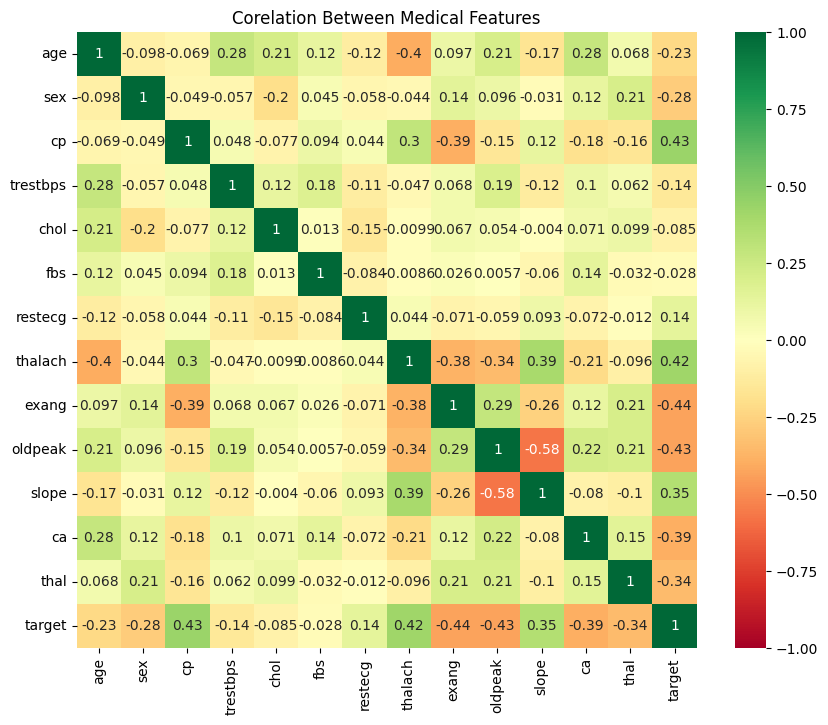

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn',center=0, vmin=-1, vmax=1)
plt.title("Corelation Between Medical Features")
plt.show()

## Creating a matrix of the features and the dependent variable vector


In [ ]:
x = df.drop("target", axis = 1)
# x = df.iloc[:, :-1]
y = df["target"]


## Splitting the dataset into the training set and the test set

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

## Feature scaling

In [ ]:
# Scale the data so large members (like glucose) don't dominate small numbers (like pregnencies)
# Freature scaling need for random forest regression
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Training the model with Random Forset

In [ ]:
# n_extimatores is used to tell how many tree we need..
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 100, random_state = 42)

In [ ]:
classifier.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

## Predicting the test set result

In [ ]:
y_pred = classifier.predict(x_test)

## Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
print(confusion_matrix(y_test, y_pred))
accuracy_score(y_test, y_pred)

[[22  5]
 [ 5 29]]


0.8360655737704918

## Predicting a new patient

In [ ]:
import numpy as np
new_data = np.array([[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0 ,0, 1]])
# For scaling
new_data_scaled = sc.transform(new_data)

prediction = classifier.predict(new_data_scaled)
print(prediction)

[0]


In [ ]:
if prediction[0] == 1:
  print("The model predict the patient has Heart Disease")
else:
  print("The model predict the patient does not have Heart Disease")

The model predict the patient does not have Heart Disease


## Selecting the most important feature

In [ ]:
df.corr()["target"].sort_values(ascending = False)

,target
target,1.000000
cp,0.433798
thalach,0.421741
slope,0.345877
restecg,0.137230
fbs,-0.028046
chol,-0.085239
trestbps,-0.144931
age,-0.225439
sex,-0.280937


In [ ]:
importances = classifier.feature_importances_
feature_names = x.columns
Feature_import_df = pd.DataFrame({"Feature" : feature_names, "Importances": importances}).sort_values("Importances", ascending = False)
print(Feature_import_df)

     Feature  Importances
7    thalach     0.126226
11        ca     0.123474
2         cp     0.123409
9    oldpeak     0.122961
12      thal     0.095832
0        age     0.082161
4       chol     0.078784
3   trestbps     0.073234
8      exang     0.062990
1        sex     0.043652
10     slope     0.038411
6    restecg     0.017193
5        fbs     0.011673


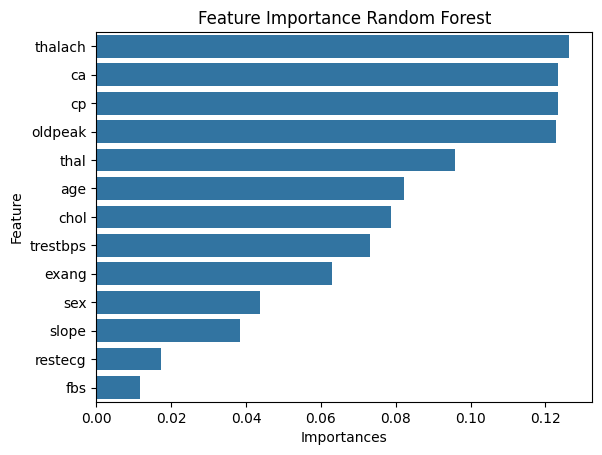

In [ ]:
sns.barplot(x = "Importances", y = "Feature", data = Feature_import_df)
plt.title("Feature Importance Random Forest")
plt.show()


## Sensivity and specificity calculation

In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[22,  5],
       [ 5, 29]])

In [ ]:
tn, fp, fn, tp = cm.ravel()

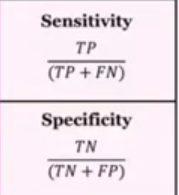

### Calculate sensitivity

The Question: Of all the people who actually have dibeties, how many did we catch?
**So, the more is better.**

In [ ]:
sensitivity = tp/(tp+fn)
print(sensitivity)

0.8529411764705882


### Calculate Specificity

The question: Of all the healthy people, how many did we correctly identify as healthy?

In [ ]:
specificity = tn / (tn + fp)
print(specificity)

0.8148148148148148


## Traning the model with logistic regration

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_classifier = LogisticRegression(max_iter = 1000)
lr_classifier.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

### Predicting the test set result

In [ ]:
y_pred_lr = lr_classifier.predict(x_test)

### Model evalulation


In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
accuracy_score_lr = accuracy_score(y_test, y_pred_lr)
print(cm_lr)
accuracy_score_lr

[[21  6]
 [ 3 31]]


0.8524590163934426

### Sensitivity and Specificity

In [ ]:
tn, fp, fn, tp = cm_lr.ravel()
sensitivity = tp/(tp+fn)
print(sensitivity)
specificity = tn / (tn + fp)
print(specificity)

0.9117647058823529
0.7777777777777778
